# Negotiation Team Analysis

Compares negotiation **win rate** and **payoff** across four strategie.

| Strategy | Source | P1 party |
|----------|--------|----------|
| **Default** | self_refine `defaultP1_defaultP2` of the **opponent's** model | single instance of the opponent model |
| **Self-Refine** | self_refine `self_refineP1_defaultP2` (RD) of the **opponent's** model | self-refining single instance |
| **Team (homo)** | `negotiation_team/*_homo_v1`, team family matched to the opponent | N copies of the opponent's model |
| **Team (hetero)** | `negotiation_team/*_hetero_v1` | gemma-3-12b-it + Ministral-3-14B + Qwen3-14B |


In [1]:
import sys, os, json, glob, warnings
sys.path.insert(0, os.path.abspath("../.."))
sys.path.insert(0, os.path.abspath("../../explorer"))  

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from analysis.common import clean_name, resource_value  

warnings.filterwarnings("ignore")
sns.set_context("poster")
sns.set_palette("colorblind")

LOGS_ROOT = os.path.abspath("../../.logs")
SIZE = "small"
GAMES = ["trading", "buysell", "ultimatum"]
GAME_LABEL = {"trading": "Trading", "buysell": "BuySell", "ultimatum": "Ultimatum"}
STRATEGY_ORDER = ["Default", "Self-Refine", "Team (homo)", "Team (hetero)"]

FAMILY_ORDER = ["gemma", "qwen", "ministral"]
def model_family(name: str):
    n = name.lower()
    for fam in FAMILY_ORDER:
        if fam in n:
            return fam
    if "mistral" in n:
        return "ministral"
    return n

print("LOGS_ROOT:", LOGS_ROOT, "| exists:", os.path.isdir(LOGS_ROOT))

LOGS_ROOT: /home/adriano/Desktop/MultiAgent-Negotiation/.logs | exists: True


## Payoff helper
Same conventions as `self_refine_analysis.ipynb`.

In [2]:
def payoff_from_summary(game, s):
    if game == "buysell":
        outcome = s["player_outcome"]            # [seller, buyer]
        return float(outcome[0]), float(outcome[1])

    d1 = resource_value(s["final_resources"][0]) - resource_value(s["initial_resources"][0])
    d2 = resource_value(s["final_resources"][1]) - resource_value(s["initial_resources"][1])

    if game == "ultimatum":
        d1 += 100
        if d1 == 100:        # no deal -> proposer keeps nothing
            d1 = 0
    return float(d1), float(d2)

## Loaders


In [3]:
def _iter_game_states(root):
    for path in glob.glob(os.path.join(root, "**", "game_state.json"), recursive=True):
        try:
            with open(path) as f:
                data = json.load(f)
        except Exception:
            continue
        last = data["game_state"][-1]
        if last.get("current_iteration") != "END":
            continue
        summary = last.get("summary")
        if summary is None:         
            continue
        yield path, summary


def _row(game, strategy, path, summary, opponent=None, team_base=None):
    p1, p2 = payoff_from_summary(game, summary)
    return {"game": game, "strategy": strategy,
            "opponent": opponent, "team_base": team_base,
            "run_id": os.path.basename(os.path.dirname(path)),
            "payoff_1": p1, "payoff_2": p2}


def _parse_team_folder(path):
    for part in path.split(os.sep):
        if part.startswith("team_") and "_vs_" in part:
            team_raw, opp_raw = part[len("team_"):].rsplit("_vs_", 1)
            return team_raw, opp_raw
    return None, None


def load_team(game, variant):
    label = f"Team ({variant})"
    root = os.path.join(LOGS_ROOT, "negotiation_team",
                        f"{game}_negotiation_team_{variant}_v1", SIZE)
    rows = []
    for path, summary in _iter_game_states(root):
        team_raw, opp_raw = _parse_team_folder(path)
        if opp_raw is None:
            continue
        if variant == "homo":
            team_base = clean_name(team_raw.split("_x3")[0])
        else:
            team_base = "trio"
        rows.append(_row(game, label, path, summary,
                         opponent=clean_name(opp_raw), team_base=team_base))
    return rows


def load_baseline(game, model_id, cond_suffix, label):
    root = os.path.join(LOGS_ROOT, "self_refine", f"{game}_self_refine_v1", SIZE)
    pair = f"{model_id}_vs_{model_id}"
    rows = []
    for path, summary in _iter_game_states(root):
        parts = path.split(os.sep)
        has_pair = any(p.startswith(pair) for p in parts)
        has_cond = any(p.endswith(cond_suffix) for p in parts)
        if has_pair and has_cond:
            rows.append(_row(game, label, path, summary, opponent=clean_name(model_id)))
    return rows


def discover_opponents():
    opps = set()
    for game in GAMES:
        for variant in ("homo", "hetero"):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1", SIZE)
            if not os.path.isdir(root):
                continue
            for d in os.listdir(root):
                if d.startswith("team_") and "_vs_" in d:
                    opps.add(d.rsplit("_vs_", 1)[1])

    def _key(o):
        fam = model_family(clean_name(o))
        return (FAMILY_ORDER.index(fam) if fam in FAMILY_ORDER else 99, o)
    return sorted(opps, key=_key)


def build_df():
    opp_ids = discover_opponents()

    # All team rows (every opponent), filtered to matched panels below.
    team_rows = []
    for game in GAMES:
        team_rows += load_team(game, "homo")
        team_rows += load_team(game, "hetero")
    team_df = pd.DataFrame(team_rows)

    # Per-opponent baselines: each opponent model's own self-play.
    base_rows = []
    for opp_id in opp_ids:
        for game in GAMES:
            base_rows += load_baseline(game, opp_id, "defaultP1_defaultP2", "Default")
            base_rows += load_baseline(game, opp_id, "self_refineP1_defaultP2", "Self-Refine")
    base_df = pd.DataFrame(base_rows)

    # Per opponent: keep hetero (all) + homo whose base family matches the opponent.
    keep = []
    for opp_id in opp_ids:
        opp = clean_name(opp_id)
        fam = model_family(opp)
        sub = team_df[team_df["opponent"] == opp]
        keep.append(sub[sub["strategy"] == "Team (hetero)"])
        keep.append(sub[(sub["strategy"] == "Team (homo)") &
                        (sub["team_base"].map(model_family) == fam)])
    team_keep = pd.concat(keep, ignore_index=True) if keep else team_df.iloc[0:0]

    df = pd.concat([base_df, team_keep], ignore_index=True)
    df["win_1"] = df["payoff_1"] > df["payoff_2"]
    df["win_2"] = df["payoff_2"] > df["payoff_1"]
    df["draw"]  = df["payoff_1"] == df["payoff_2"]
    df["strategy"] = pd.Categorical(df["strategy"], categories=STRATEGY_ORDER, ordered=True)
    df["game"] = pd.Categorical(df["game"], categories=GAMES, ordered=True)
    df["opponent"] = pd.Categorical(df["opponent"],
                                    categories=[clean_name(o) for o in opp_ids], ordered=True)
    return df


OPPONENTS = [clean_name(o) for o in discover_opponents()]
print("opponents discovered:", OPPONENTS)

df = build_df()
print("rows:", len(df))
df.head()

opponents discovered: ['gemma-3-12b-it', 'qwen3-14b', 'ministral-3-14b-2512']
rows: 964


,game,strategy,opponent,team_base,run_id,payoff_1,payoff_2,win_1,win_2,draw
0,trading,Default,gemma-3-12b-it,None,1779033809585,-1.0,1.0,False,True,False
1,trading,Default,gemma-3-12b-it,None,1779032293732,-2.0,2.0,False,True,False
2,trading,Default,gemma-3-12b-it,None,1779034769422,-5.0,5.0,False,True,False
3,trading,Default,gemma-3-12b-it,None,1779038398618,2.0,-2.0,True,False,False
4,trading,Default,gemma-3-12b-it,None,1779033544421,-8.0,8.0,False,True,False


## Sample sizes
Run counts per opponent × game × strategy (the denominators behind every plot below).

In [4]:
counts = df.pivot_table(index=["opponent", "game"], columns="strategy", values="run_id",
                        aggfunc="count", observed=True)
counts

strategy                        Default  Self-Refine  Team (homo)  \
opponent             game                                           
gemma-3-12b-it       trading         30           29           29   
                     buysell         30           29           30   
                     ultimatum       30           29           30   
qwen3-14b            trading         20           14           29   
                     buysell         24           30           30   
                     ultimatum       19           30           30   
ministral-3-14b-2512 trading         26           28           19   
                     buysell         29           28           16   
                     ultimatum       30           23           28   

strategy                        Team (hetero)  
opponent             game                      
gemma-3-12b-it       trading               28  
                     buysell               30  
                     ultimatum             30  
qwen3-14b            trading               24  
                     buysell               27  
                     ultimatum             30  
ministral-3-14b-2512 trading               26  
                     buysell               23  
                     ultimatum             27

## P1 win rate
Strict P1 wins (`payoff_1 > payoff_2`), one panel per opponent. Draw rate reported below.

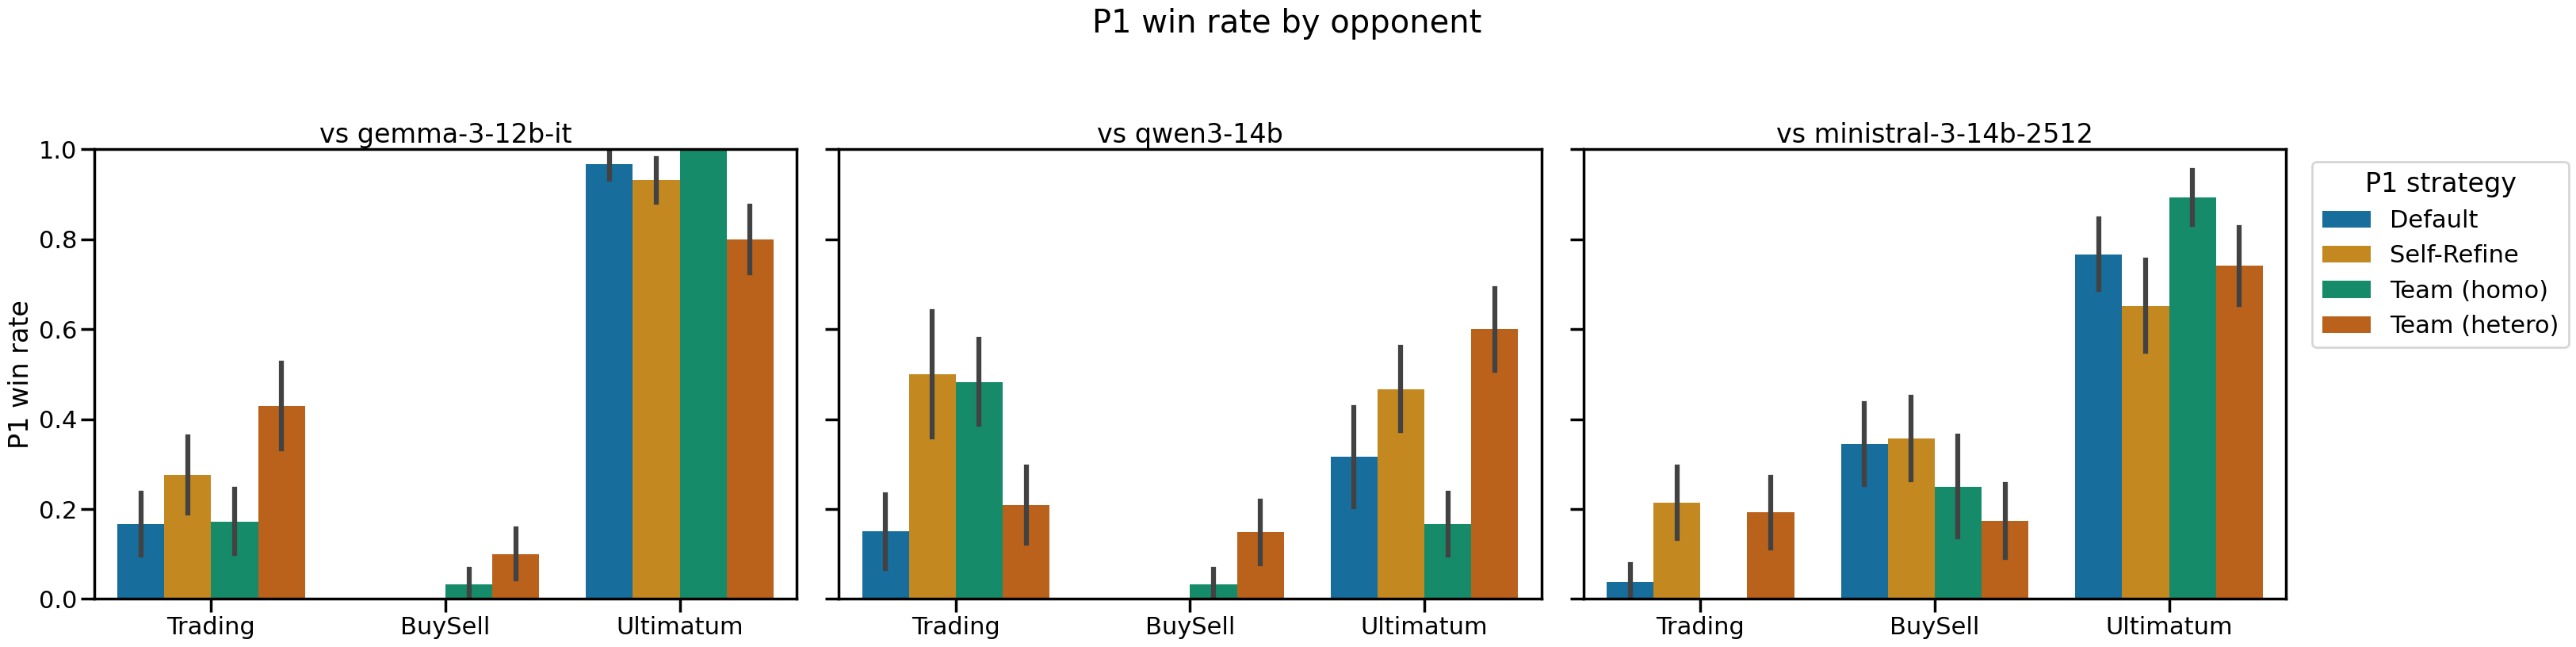

Draw rate per opponent x game x strategy:


strategy                        Default  Self-Refine  Team (homo)  \
opponent             game                                           
gemma-3-12b-it       trading       0.10         0.03         0.03   
                     buysell       0.17         0.03         0.03   
                     ultimatum     0.03         0.07         0.00   
qwen3-14b            trading       0.55         0.14         0.38   
                     buysell       0.12         0.07         0.20   
                     ultimatum     0.68         0.43         0.77   
ministral-3-14b-2512 trading       0.12         0.07         0.11   
                     buysell       0.21         0.21         0.31   
                     ultimatum     0.20         0.35         0.07   

strategy                        Team (hetero)  
opponent             game                      
gemma-3-12b-it       trading             0.04  
                     buysell             0.30  
                     ultimatum           0.17  
qwen3-14b            trading             0.04  
                     buysell             0.22  
                     ultimatum           0.33  
ministral-3-14b-2512 trading             0.08  
                     buysell             0.43  
                     ultimatum           0.19

In [5]:
# One panel per opponent; within each: x=game, hue=strategy. Shared y in [0,1].
opps = [o for o in OPPONENTS if not df[df["opponent"] == o].empty]
fig, axes = plt.subplots(1, len(opps), figsize=(11 * len(opps), 8), sharey=True, squeeze=False)
axes = axes[0]
for ax, opp in zip(axes, opps):
    sub = df[df["opponent"] == opp]
    sns.barplot(data=sub, x="game", y="win_1", hue="strategy",
                hue_order=STRATEGY_ORDER, errorbar="se", ax=ax,
                legend=(opp == opps[-1]))
    ax.set_title(f"vs {opp}")
    ax.set_xlabel(""); ax.set_ylim(0, 1)
    ax.set_ylabel("P1 win rate" if opp == opps[0] else "")
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
axes[-1].legend(title="P1 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("P1 win rate by opponent", y=1.04)
plt.tight_layout()
#fig.savefig("negotiation_team_win_rate_by_opponent.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

print("Draw rate per opponent x game x strategy:")
df.pivot_table(index=["opponent", "game"], columns="strategy", values="draw",
               aggfunc="mean", observed=True).round(2)

## P1 payoff
Payoff scales differ per game, so each (opponent, game) gets its own panel — rows are opponents, columns are games.

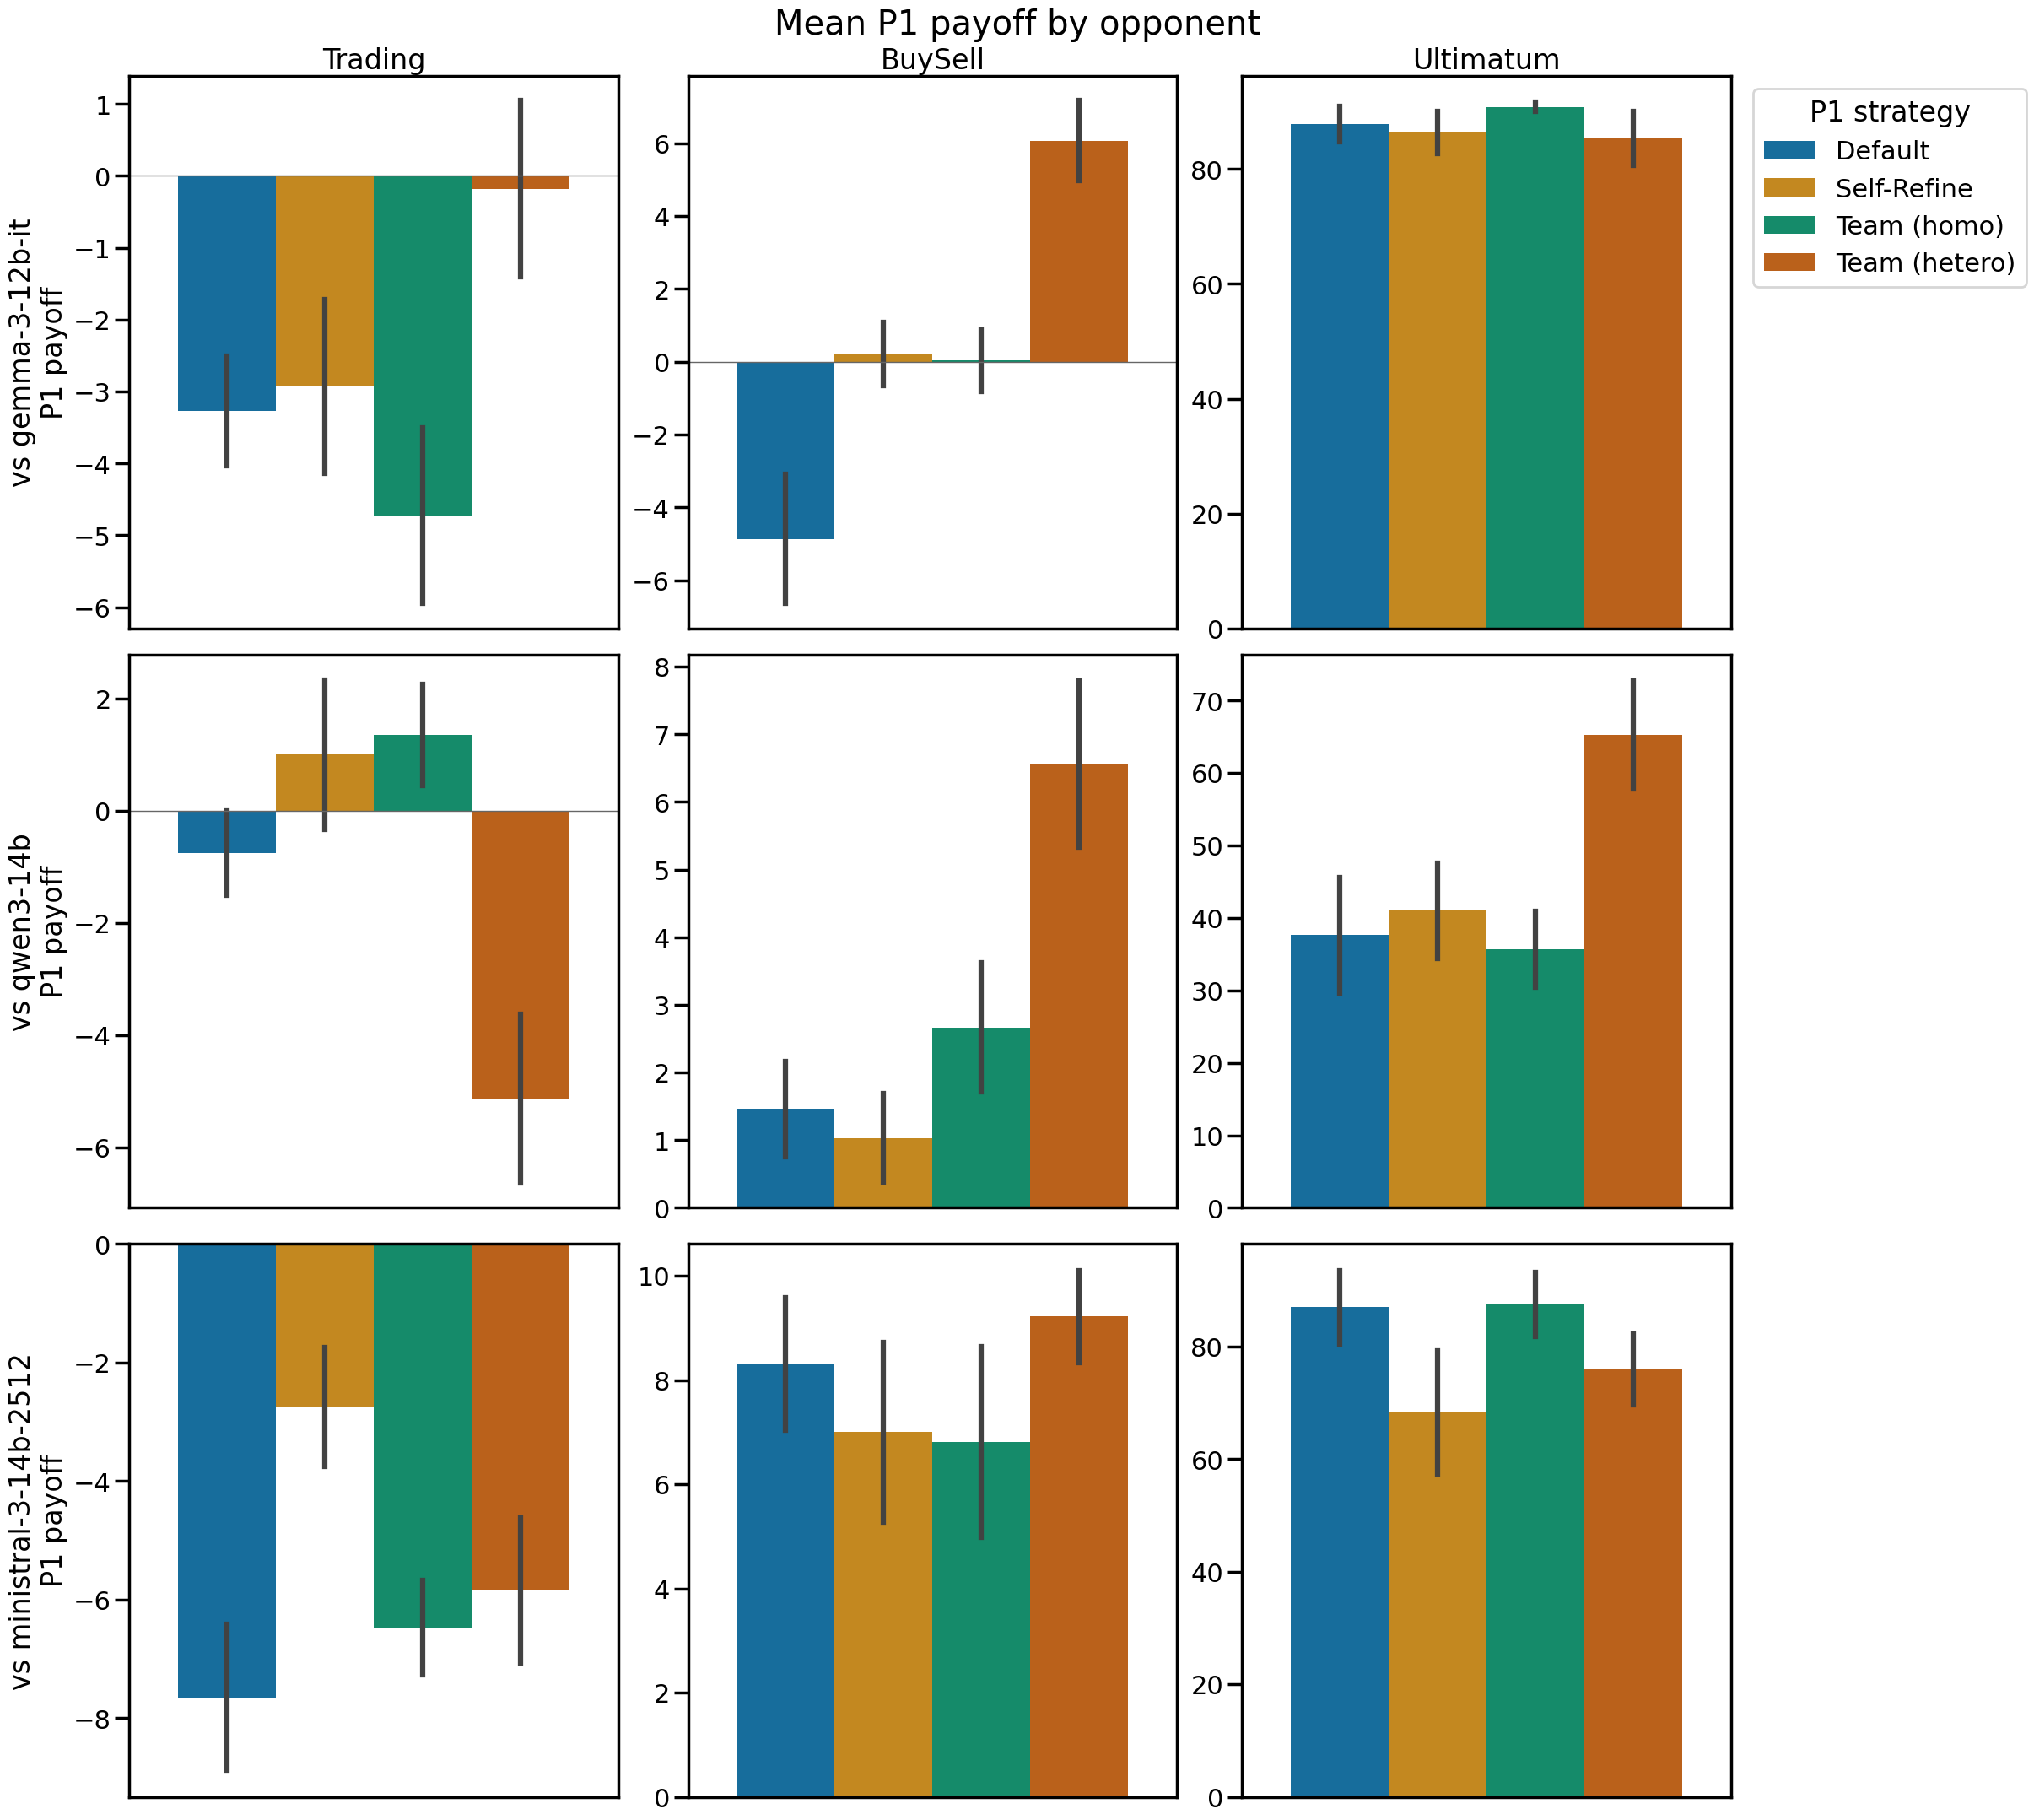

In [6]:
# Grid: rows = opponent, cols = game. Independent y per game (payoffs can be negative).
opps = [o for o in OPPONENTS if not df[df["opponent"] == o].empty]
nrows, ncols = len(opps), len(GAMES)
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows),
                         squeeze=False, constrained_layout=True)
for r, opp in enumerate(opps):
    for c, game in enumerate(GAMES):
        ax = axes[r][c]
        sub = df[(df["opponent"] == opp) & (df["game"] == game)].copy()
        sub["_x"] = GAME_LABEL[game]  # single category -> hued bars centered
        last_panel = (r == 0 and c == ncols - 1)
        sns.barplot(data=sub, x="_x", y="payoff_1", hue="strategy",
                    hue_order=STRATEGY_ORDER, errorbar="se", ax=ax, legend=last_panel)
        ax.axhline(0, color="0.4", lw=1)
        ax.set_xlabel(""); ax.set_xticks([])
        ax.set_title(GAME_LABEL[game] if r == 0 else "")
        ax.set_ylabel(f"vs {opp}\nP1 payoff" if c == 0 else "")
axes[0][-1].legend(title="P1 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Mean P1 payoff by opponent", y=1.02)
#fig.savefig("negotiation_team_payoff_by_opponent_and_game.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

## Homogeneous vs Heterogeneous teams
Zoom on the two team strategies, faceted per opponent (win rate top row, payoff bottom row).

> **Matched-panel rule:** in each opponent panel, `Team (homo)` is the homogeneous team whose model family
> matches the opponent (gemma_x3 vs gemma, qwen_x3 vs qwen, …). Cross-family homo runs (e.g. ministral_x3 vs
> qwen), should any be gathered, are intentionally excluded from these matched panels.

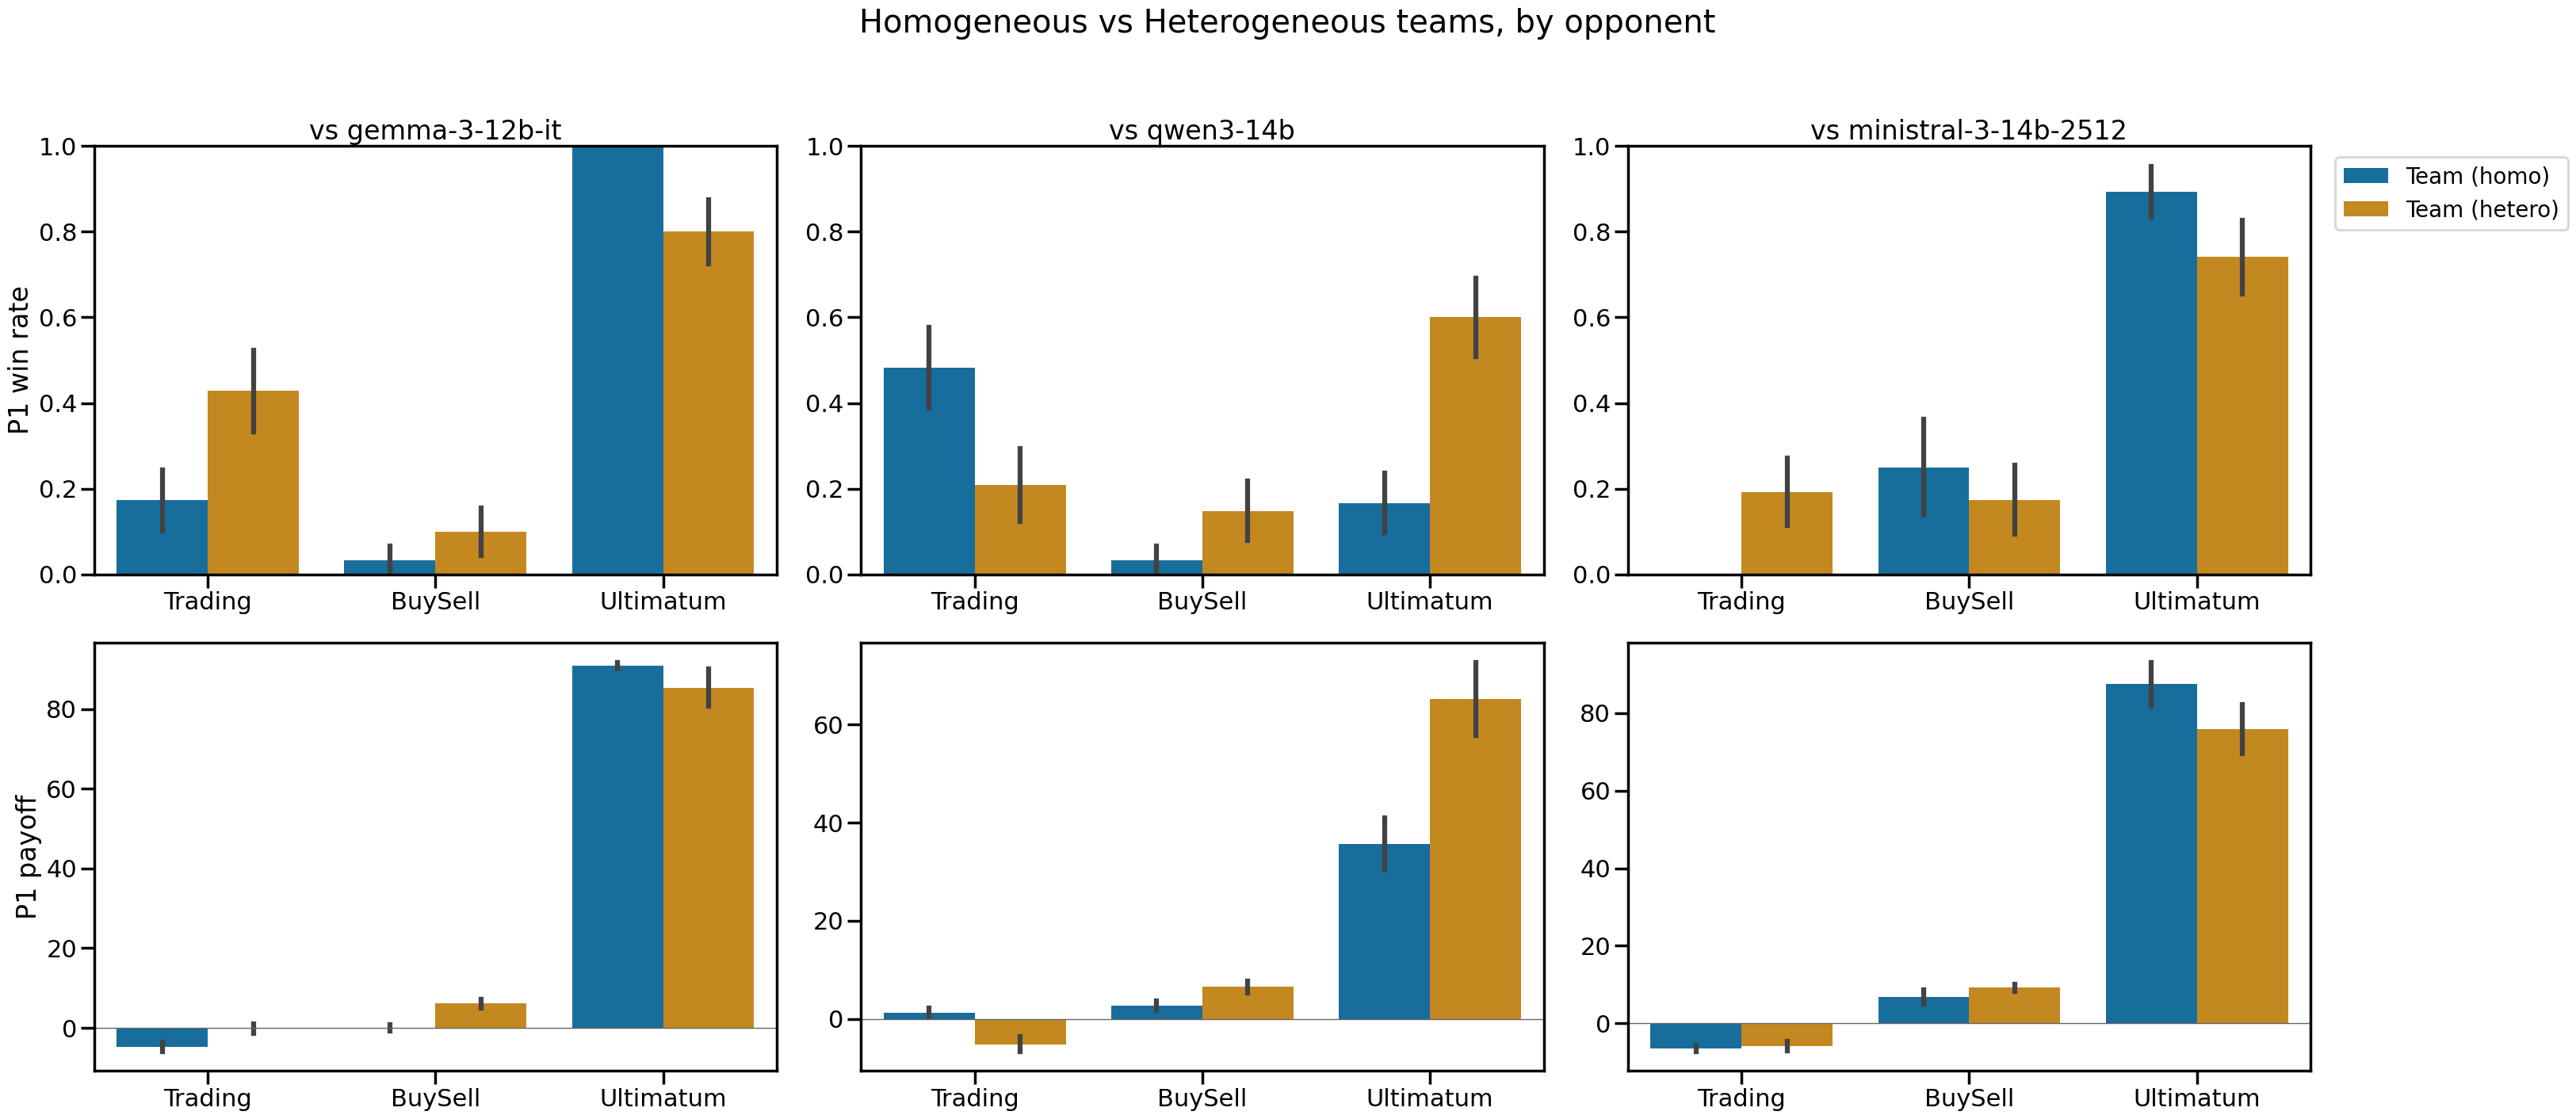

In [7]:
# Zoom on the two team strategies, faceted per opponent.
# Rows: win rate / payoff; columns: opponent.
teams = df[df["strategy"].isin(["Team (homo)", "Team (hetero)"])].copy()
teams["strategy"] = teams["strategy"].cat.remove_unused_categories()
opps = [o for o in OPPONENTS if not teams[teams["opponent"] == o].empty]

fig, axes = plt.subplots(2, len(opps), figsize=(11 * len(opps), 14), squeeze=False)
for c, opp in enumerate(opps):
    sub = teams[teams["opponent"] == opp]
    sns.barplot(data=sub, x="game", y="win_1", hue="strategy", errorbar="se",
                ax=axes[0][c], legend=(c == len(opps) - 1))
    axes[0][c].set_title(f"vs {opp}")
    axes[0][c].set_ylim(0, 1); axes[0][c].set_xlabel("")
    axes[0][c].set_ylabel("P1 win rate" if c == 0 else "")

    sns.barplot(data=sub, x="game", y="payoff_1", hue="strategy", errorbar="se",
                ax=axes[1][c], legend=False)
    axes[1][c].axhline(0, color="0.4", lw=1); axes[1][c].set_xlabel("")
    axes[1][c].set_ylabel("P1 payoff" if c == 0 else "")

for ax in axes.flat:
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
axes[0][-1].legend(title="", fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Homogeneous vs Heterogeneous teams, by opponent", y=1.02)
plt.tight_layout()
#fig.savefig("negotiation_team_homo_vs_hetero_by_opponent.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

# Team as P2


In [8]:
# --- P2-focal loaders (team in the P2 slot) -------------------------------------------
# Mirror the P1 loaders above. Differences: read from the *_v1_p2 dirs, parse the flipped
# '<opp>_vs_team_<TEAM>' folder, and the focal party is P2 (we plot payoff_2 / win_2).

def _parse_team_folder_p2(path):
    """Extract (opp_raw, team_raw) from the '<OPP>_vs_team_<TEAM>' path segment.

    Returns (None, None) if no such segment is found.
      homo  : gemma-3-12b-it_vs_team_gemma-3-12b-it_x3            -> ('gemma-3-12b-it', 'gemma-3-12b-it_x3')
      hetero: qwen3-14b_vs_team_gemma-3-12b-it+...+qwen3-14b      -> ('qwen3-14b', 'gemma-3-12b-it+...+qwen3-14b')
    """
    for part in path.split(os.sep):
        if "_vs_team_" in part:
            opp_raw, team_raw = part.split("_vs_team_", 1)
            return opp_raw, team_raw
    return None, None


def load_team_p2(game, variant):
    """variant in {'homo','hetero'} -> rows tagged 'Team (homo)'/'Team (hetero)' from the
    *_v1_p2 logs, each carrying its parsed `opponent` (the P1 model, cleaned) and `team_base`.
    Same row schema as load_team; the team's payoff is payoff_2 (focal = P2)."""
    label = f"Team ({variant})"
    root = os.path.join(LOGS_ROOT, "negotiation_team",
                        f"{game}_negotiation_team_{variant}_v1_p2", SIZE)
    rows = []
    for path, summary in _iter_game_states(root):
        opp_raw, team_raw = _parse_team_folder_p2(path)
        if opp_raw is None:
            continue
        if variant == "homo":
            team_base = clean_name(team_raw.split("_x3")[0])
        else:
            team_base = "trio"
        rows.append(_row(game, label, path, summary,
                         opponent=clean_name(opp_raw), team_base=team_base))
    return rows


# Baselines are the opponent model's own self-play; load_baseline already returns both
# payoffs, so it is reused verbatim — only the Self-Refine condition suffix flips to the
# P2 side (defaultP1_self_refineP2) in build_df_p2.
load_baseline_p2 = load_baseline


def discover_opponents_p2():
    """Raw P1-opponent ids present across all *_v1_p2 team logs, family-ordered."""
    opps = set()
    for game in GAMES:
        for variant in ("homo", "hetero"):
            root = os.path.join(LOGS_ROOT, "negotiation_team",
                                f"{game}_negotiation_team_{variant}_v1_p2", SIZE)
            if not os.path.isdir(root):
                continue
            for d in os.listdir(root):
                if "_vs_team_" in d:
                    opps.add(d.split("_vs_team_", 1)[0])

    def _key(o):
        fam = model_family(clean_name(o))
        return (FAMILY_ORDER.index(fam) if fam in FAMILY_ORDER else 99, o)
    return sorted(opps, key=_key)


def build_df_p2():
    opp_ids = discover_opponents_p2()

    # All team rows (every P1 opponent), filtered to matched panels below.
    team_rows = []
    for game in GAMES:
        team_rows += load_team_p2(game, "homo")
        team_rows += load_team_p2(game, "hetero")
    team_df = pd.DataFrame(team_rows)

    # Per-opponent baselines: each opponent model's own self-play, focal = P2.
    base_rows = []
    for opp_id in opp_ids:
        for game in GAMES:
            base_rows += load_baseline_p2(game, opp_id, "defaultP1_defaultP2", "Default")
            base_rows += load_baseline_p2(game, opp_id, "defaultP1_self_refineP2", "Self-Refine")
    base_df = pd.DataFrame(base_rows)

    # Per opponent: keep hetero (all) + homo whose base family matches the opponent.
    keep = []
    for opp_id in opp_ids:
        opp = clean_name(opp_id)
        fam = model_family(opp)
        sub = team_df[team_df["opponent"] == opp]
        keep.append(sub[sub["strategy"] == "Team (hetero)"])
        keep.append(sub[(sub["strategy"] == "Team (homo)") &
                        (sub["team_base"].map(model_family) == fam)])
    team_keep = pd.concat(keep, ignore_index=True) if keep else team_df.iloc[0:0]

    df = pd.concat([base_df, team_keep], ignore_index=True)
    df["win_1"] = df["payoff_1"] > df["payoff_2"]
    df["win_2"] = df["payoff_2"] > df["payoff_1"]
    df["draw"]  = df["payoff_1"] == df["payoff_2"]
    df["strategy"] = pd.Categorical(df["strategy"], categories=STRATEGY_ORDER, ordered=True)
    df["game"] = pd.Categorical(df["game"], categories=GAMES, ordered=True)
    df["opponent"] = pd.Categorical(df["opponent"],
                                    categories=[clean_name(o) for o in opp_ids], ordered=True)
    return df


OPPONENTS_P2 = [clean_name(o) for o in discover_opponents_p2()]
print("P2 opponents discovered:", OPPONENTS_P2)

df_p2 = build_df_p2()
print("rows:", len(df_p2))
df_p2.head()

P2 opponents discovered: ['gemma-3-12b-it', 'qwen3-14b', 'ministral-3-14b-2512']
rows: 1014


,game,strategy,opponent,team_base,run_id,payoff_1,payoff_2,win_1,win_2,draw
0,trading,Default,gemma-3-12b-it,None,1779033809585,-1.0,1.0,False,True,False
1,trading,Default,gemma-3-12b-it,None,1779032293732,-2.0,2.0,False,True,False
2,trading,Default,gemma-3-12b-it,None,1779034769422,-5.0,5.0,False,True,False
3,trading,Default,gemma-3-12b-it,None,1779038398618,2.0,-2.0,True,False,False
4,trading,Default,gemma-3-12b-it,None,1779033544421,-8.0,8.0,False,True,False


## P2 win rate
Strict P2 wins (`payoff_2 > payoff_1`), one panel per P1 opponent. Draw rate reported below.

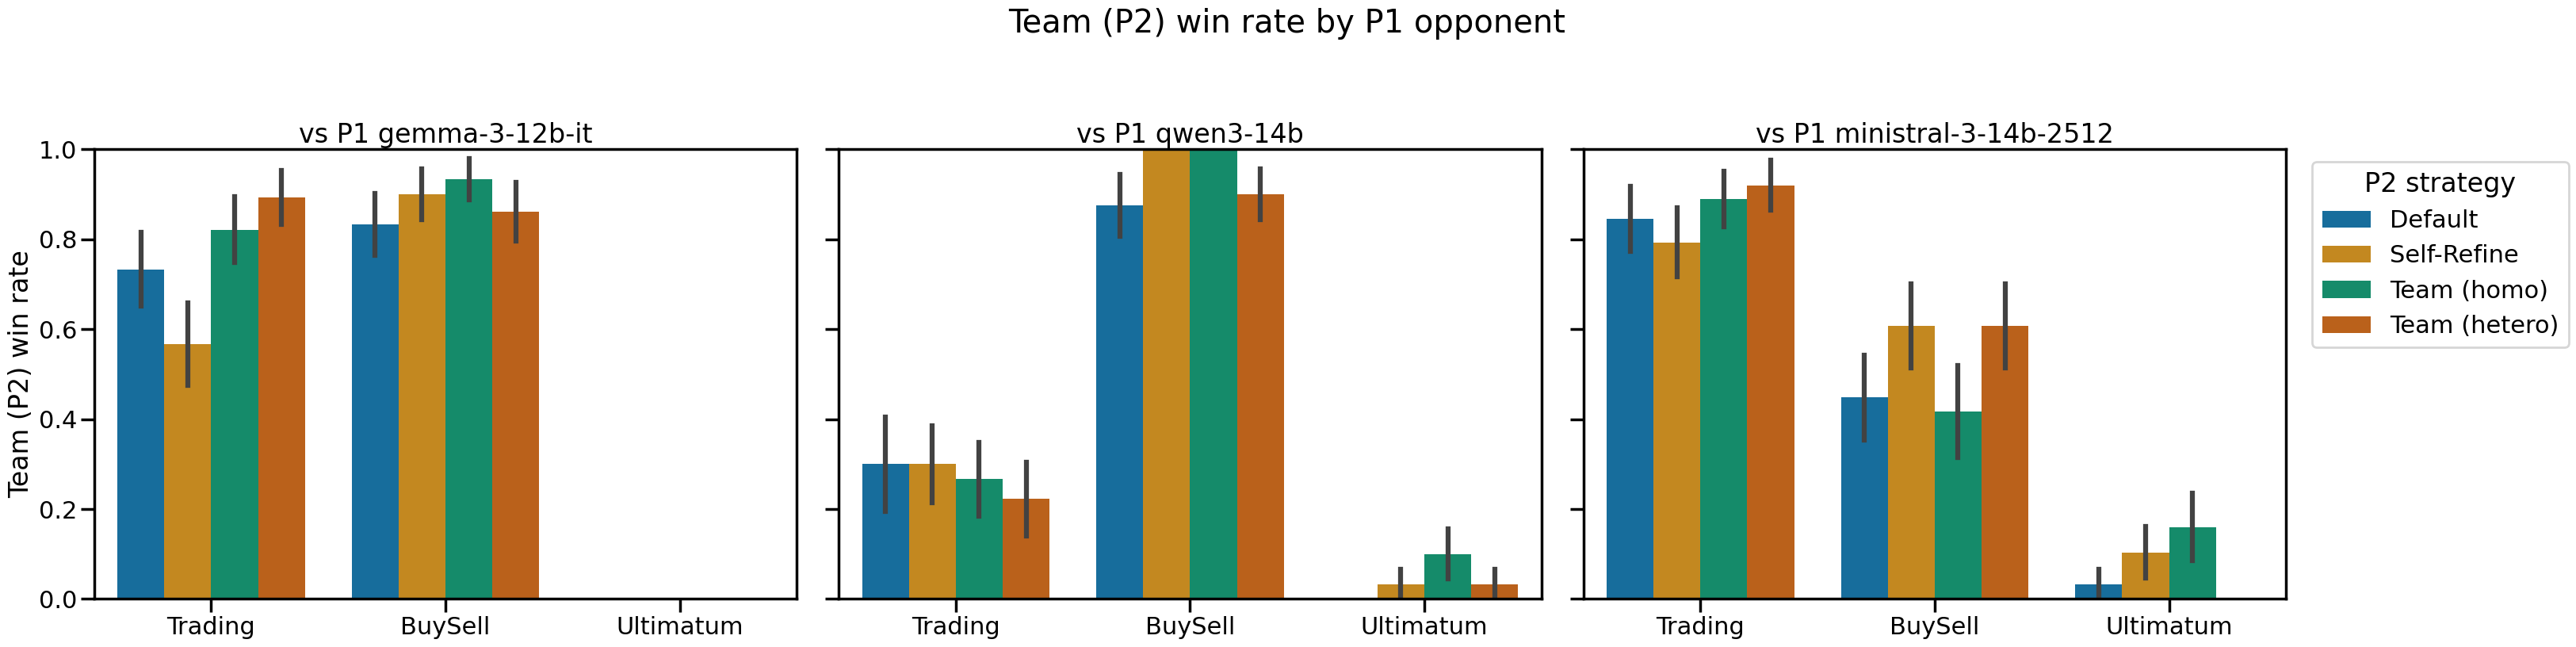

Draw rate per opponent x game x strategy:


strategy                        Default  Self-Refine  Team (homo)  \
opponent             game                                           
gemma-3-12b-it       trading       0.10         0.00         0.04   
                     buysell       0.17         0.10         0.07   
                     ultimatum     0.03         0.00         0.00   
qwen3-14b            trading       0.55         0.43         0.63   
                     buysell       0.12         0.00         0.00   
                     ultimatum     0.68         0.53         0.47   
ministral-3-14b-2512 trading       0.12         0.07         0.07   
                     buysell       0.21         0.11         0.38   
                     ultimatum     0.20         0.21         0.20   

strategy                        Team (hetero)  
opponent             game                      
gemma-3-12b-it       trading             0.07  
                     buysell             0.14  
                     ultimatum           0.00  
qwen3-14b            trading             0.52  
                     buysell             0.10  
                     ultimatum           0.37  
ministral-3-14b-2512 trading             0.04  
                     buysell             0.29  
                     ultimatum           0.30

In [9]:
# One panel per P1 opponent; within each: x=game, hue=strategy. Shared y in [0,1].
opps = [o for o in OPPONENTS_P2 if not df_p2[df_p2["opponent"] == o].empty]
fig, axes = plt.subplots(1, len(opps), figsize=(11 * len(opps), 8), sharey=True, squeeze=False)
axes = axes[0]
for ax, opp in zip(axes, opps):
    sub = df_p2[df_p2["opponent"] == opp]
    sns.barplot(data=sub, x="game", y="win_2", hue="strategy",
                hue_order=STRATEGY_ORDER, errorbar="se", ax=ax,
                legend=(opp == opps[-1]))
    ax.set_title(f"vs P1 {opp}")
    ax.set_xlabel(""); ax.set_ylim(0, 1)
    ax.set_ylabel("Team (P2) win rate" if opp == opps[0] else "")
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
axes[-1].legend(title="P2 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Team (P2) win rate by P1 opponent", y=1.04)
plt.tight_layout()
#fig.savefig("negotiation_team_p2_win_rate_by_opponent.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

print("Draw rate per opponent x game x strategy:")
df_p2.pivot_table(index=["opponent", "game"], columns="strategy", values="draw",
                  aggfunc="mean", observed=True).round(2)

## P2 payoff
Payoff scales differ per game, so each (P1 opponent, game) gets its own panel — rows are opponents, columns are games.

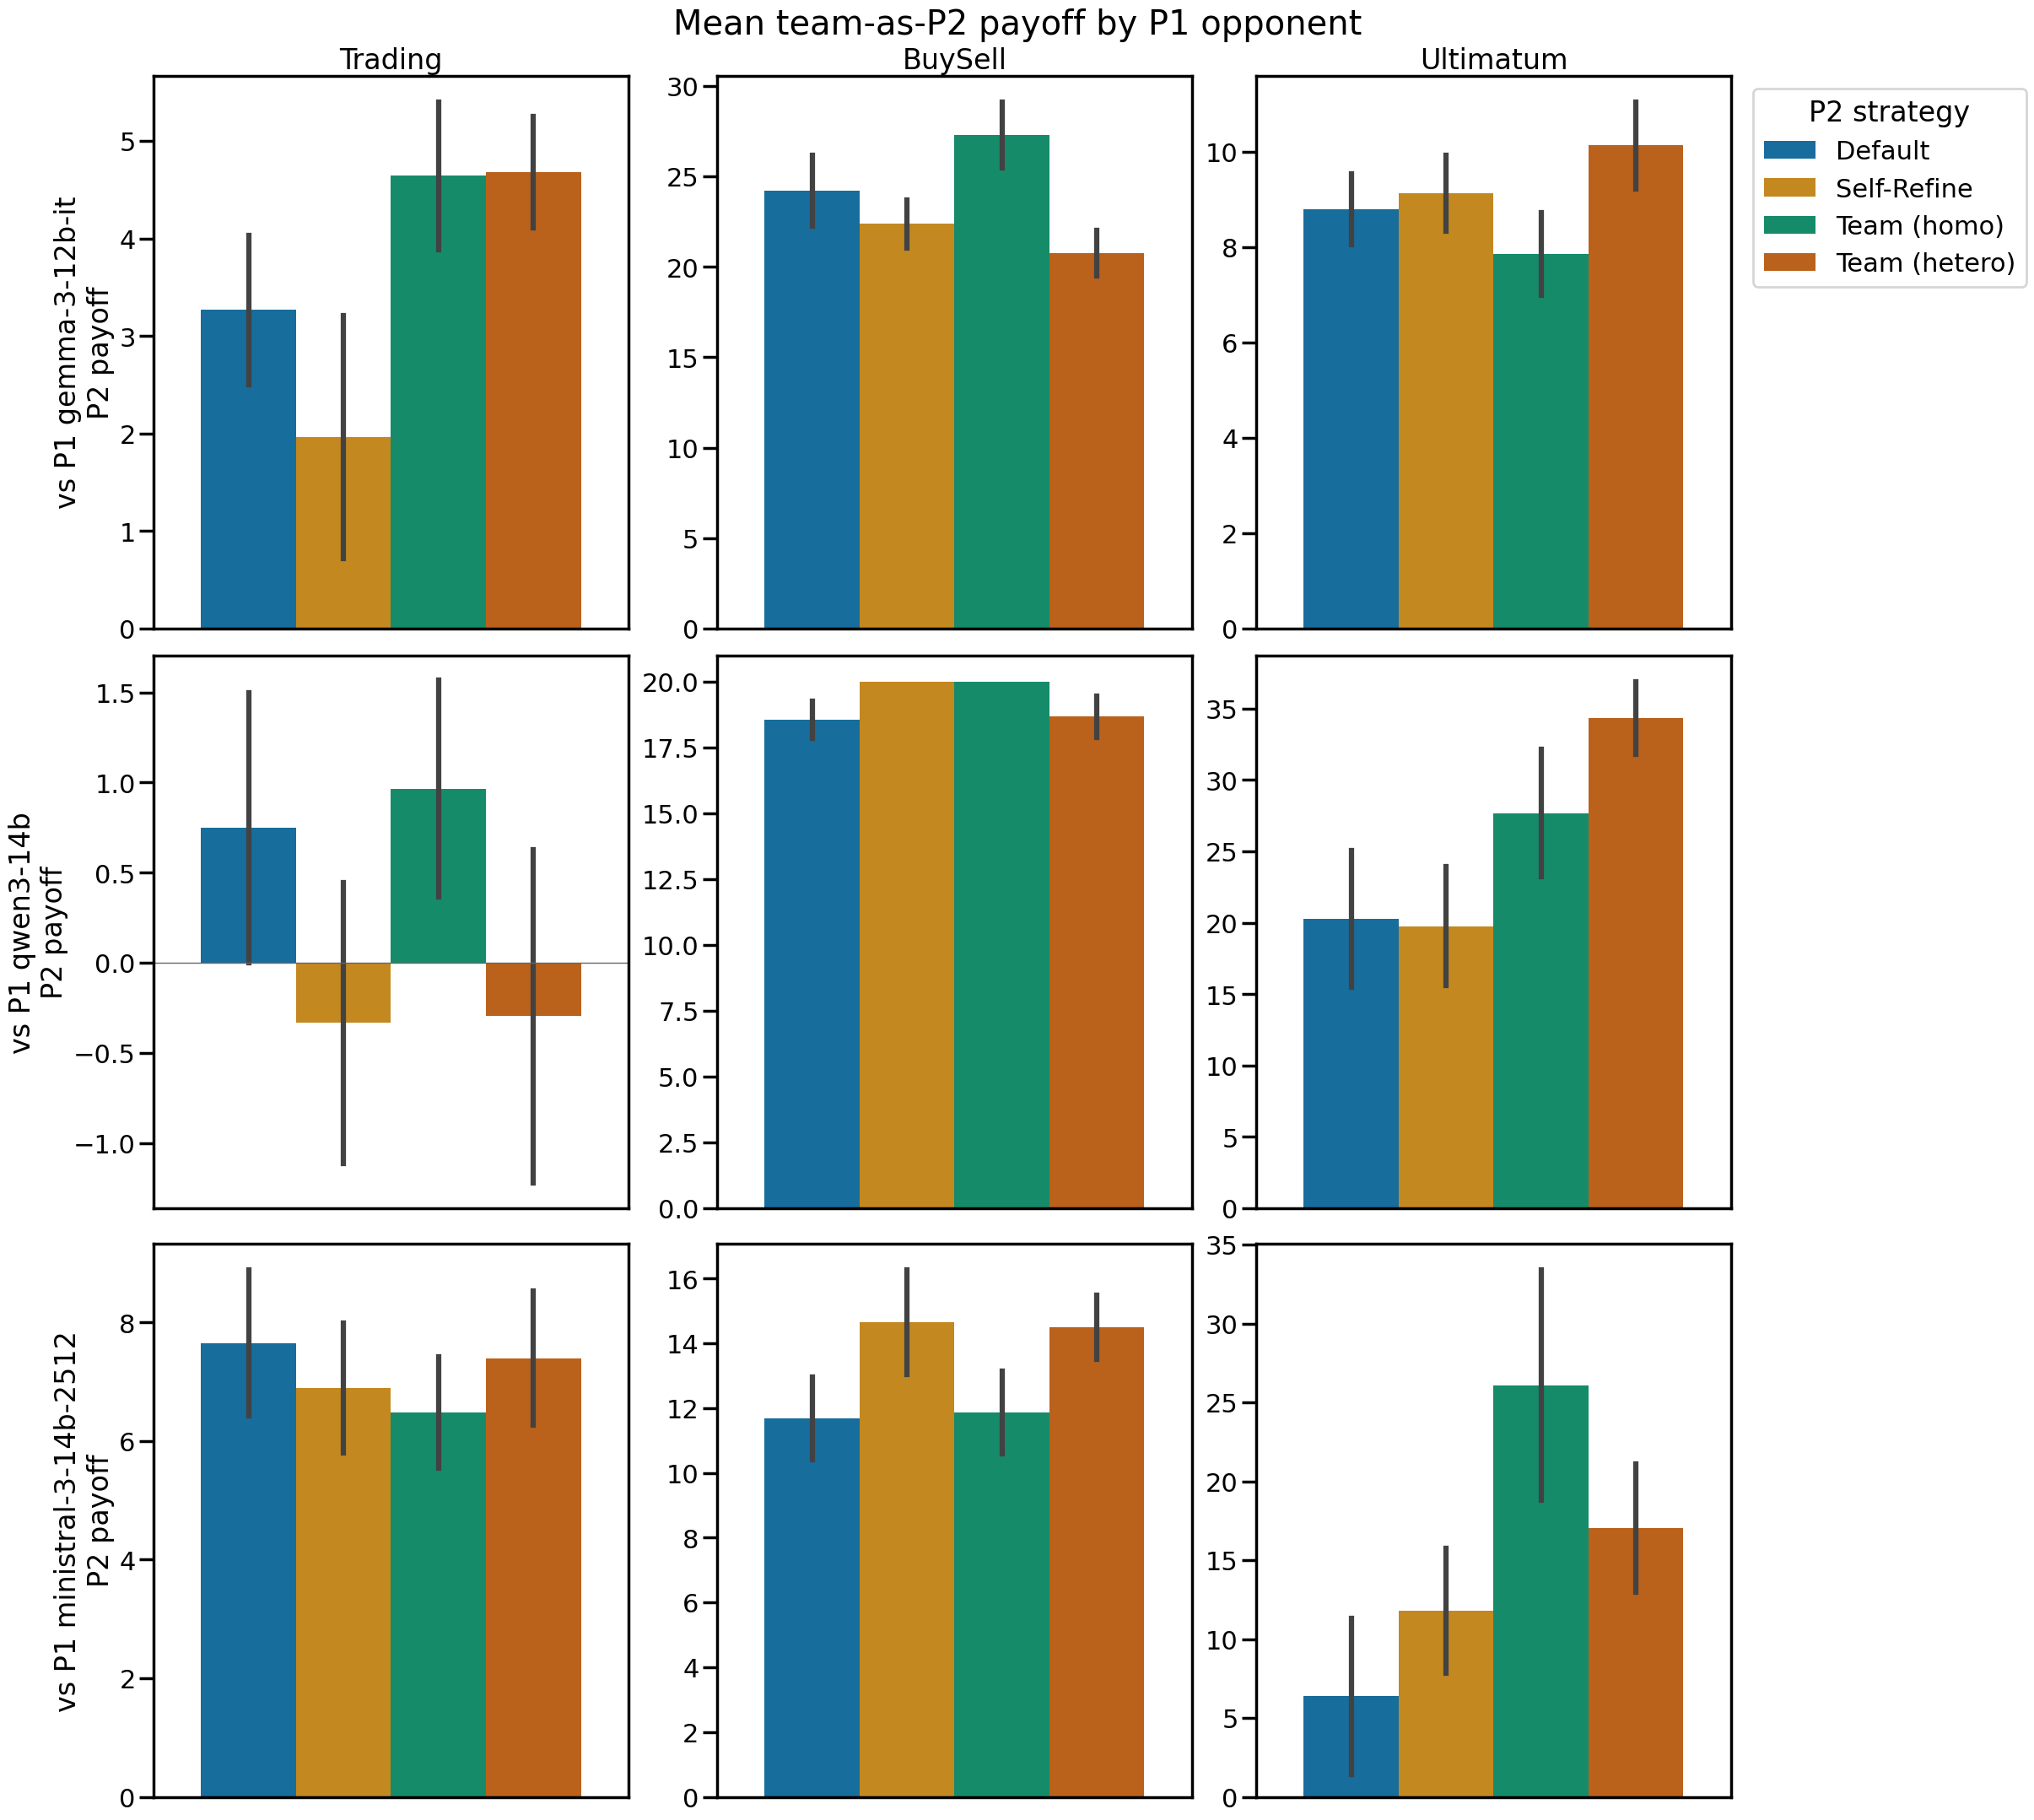

In [10]:
# Grid: rows = P1 opponent, cols = game. Independent y per game (payoffs can be negative).
opps = [o for o in OPPONENTS_P2 if not df_p2[df_p2["opponent"] == o].empty]
nrows, ncols = len(opps), len(GAMES)
fig, axes = plt.subplots(nrows, ncols, figsize=(8 * ncols, 7 * nrows),
                         squeeze=False, constrained_layout=True)
for r, opp in enumerate(opps):
    for c, game in enumerate(GAMES):
        ax = axes[r][c]
        sub = df_p2[(df_p2["opponent"] == opp) & (df_p2["game"] == game)].copy()
        sub["_x"] = GAME_LABEL[game]  # single category -> hued bars centered
        last_panel = (r == 0 and c == ncols - 1)
        sns.barplot(data=sub, x="_x", y="payoff_2", hue="strategy",
                    hue_order=STRATEGY_ORDER, errorbar="se", ax=ax, legend=last_panel)
        ax.axhline(0, color="0.4", lw=1)
        ax.set_xlabel(""); ax.set_xticks([])
        ax.set_title(GAME_LABEL[game] if r == 0 else "")
        ax.set_ylabel(f"vs P1 {opp}\nP2 payoff" if c == 0 else "")
axes[0][-1].legend(title="P2 strategy", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.suptitle("Mean team-as-P2 payoff by P1 opponent", y=1.02)
#fig.savefig("negotiation_team_p2_payoff_by_opponent_and_game.png", bbox_inches="tight")  # save BEFORE show()
plt.show()

## Homogeneous vs Heterogeneous teams (P2)
Zoom on the two team strategies as P2, faceted per P1 opponent (win rate top row, payoff bottom row).

> **Matched-panel rule** (same as the P1 section): in each opponent panel, `Team (homo)` is the
> homogeneous team whose model family matches the P1 opponent. Cross-family homo runs are excluded.

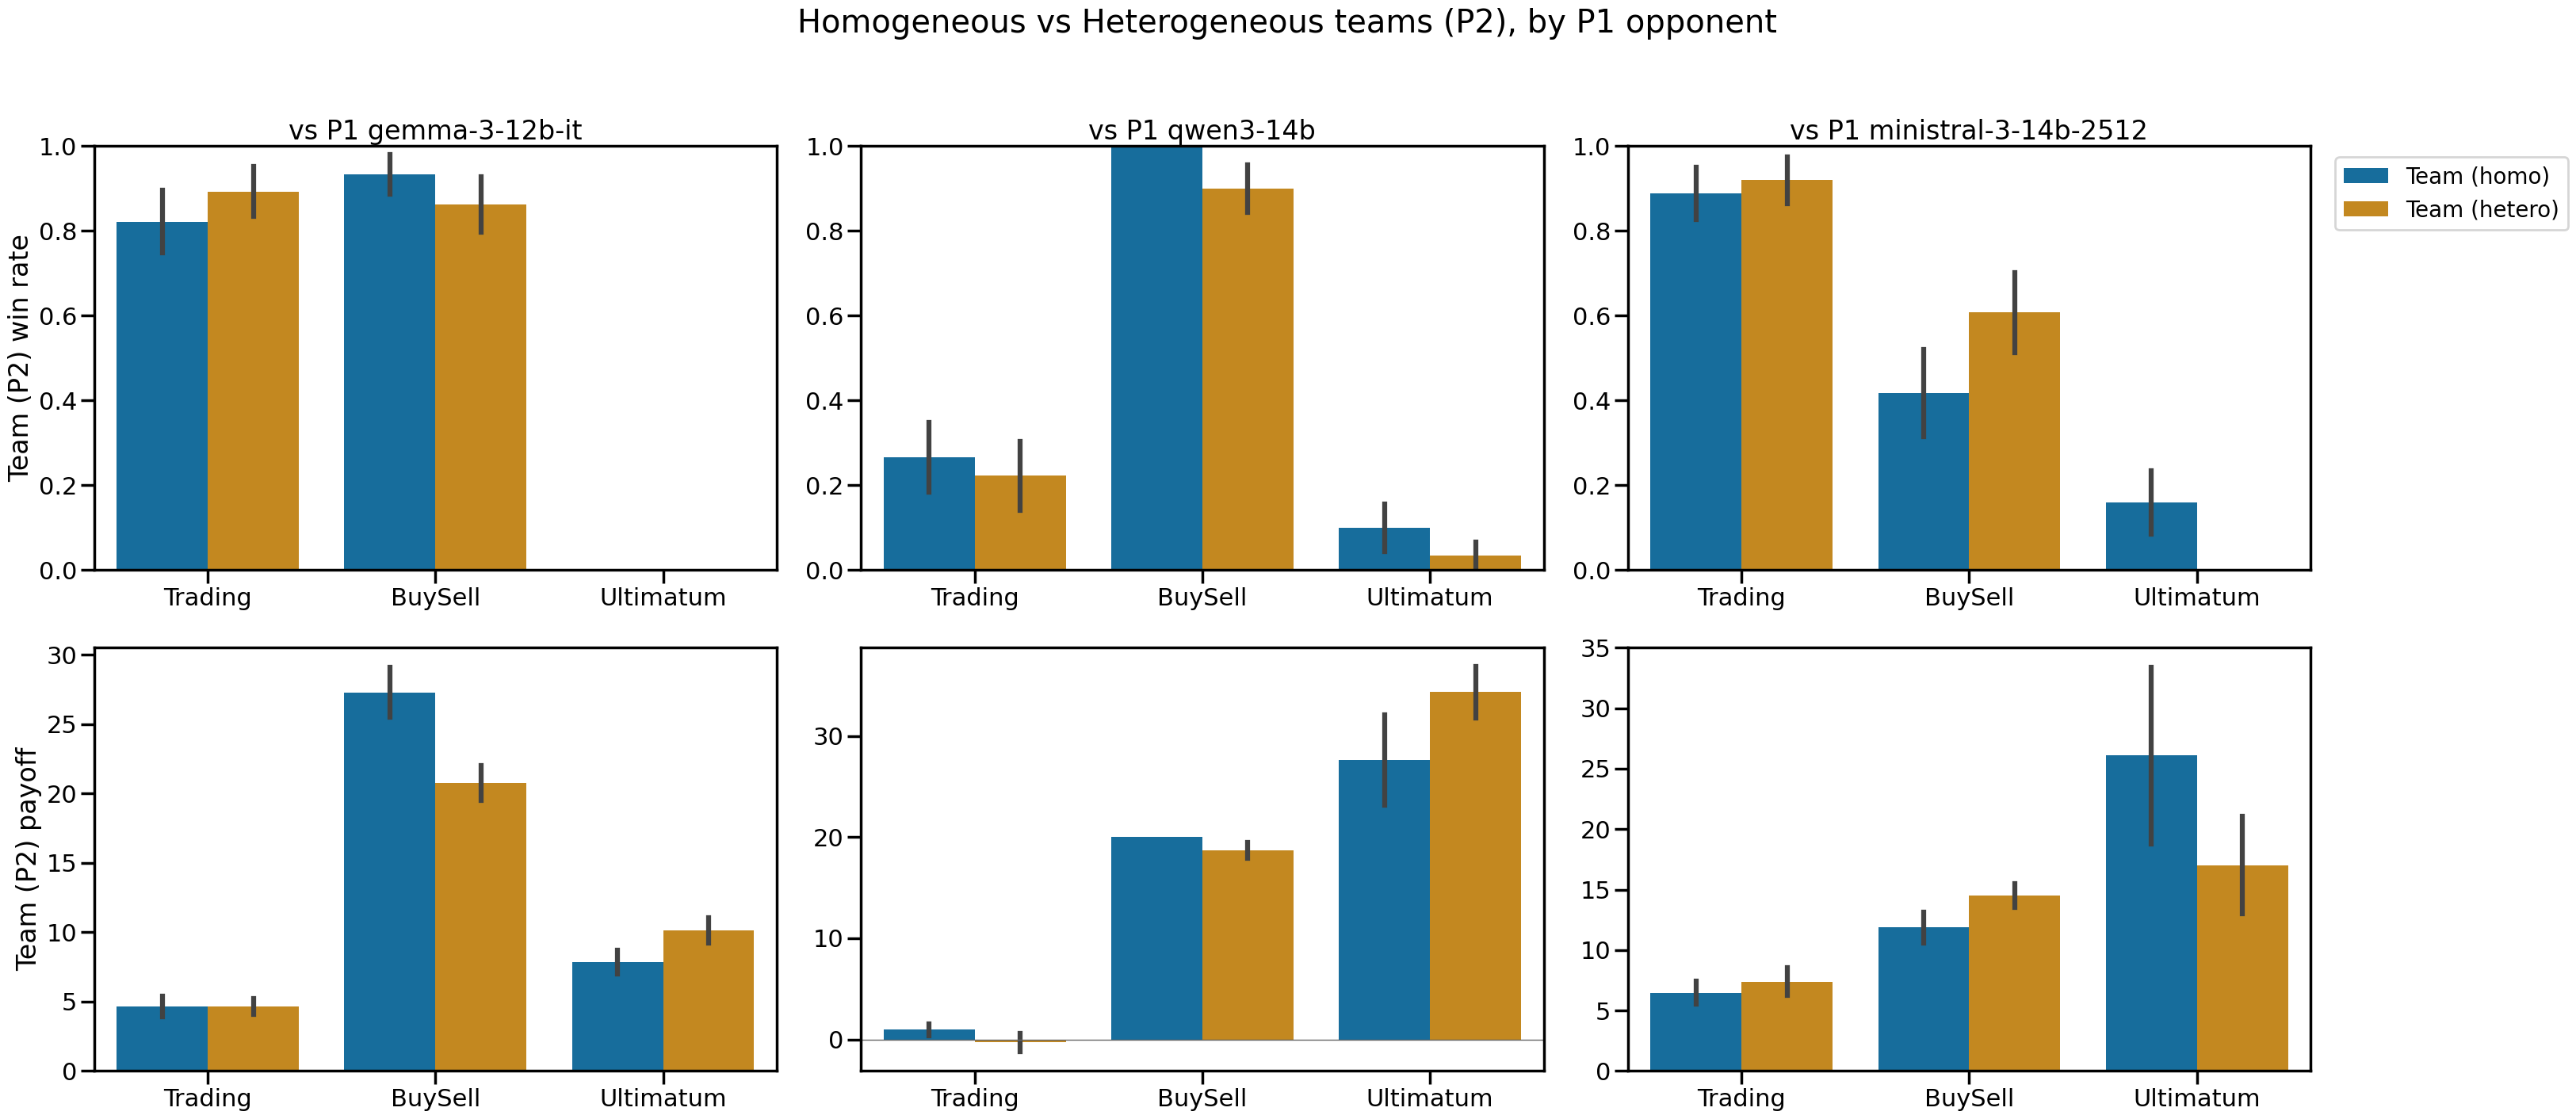

In [11]:
# Zoom on the two team strategies (as P2), faceted per P1 opponent.
# Rows: win rate / payoff; columns: opponent.
teams = df_p2[df_p2["strategy"].isin(["Team (homo)", "Team (hetero)"])].copy()
teams["strategy"] = teams["strategy"].cat.remove_unused_categories()
opps = [o for o in OPPONENTS_P2 if not teams[teams["opponent"] == o].empty]

fig, axes = plt.subplots(2, len(opps), figsize=(11 * len(opps), 14), squeeze=False)
for c, opp in enumerate(opps):
    sub = teams[teams["opponent"] == opp]
    sns.barplot(data=sub, x="game", y="win_2", hue="strategy", errorbar="se",
                ax=axes[0][c], legend=(c == len(opps) - 1))
    axes[0][c].set_title(f"vs P1 {opp}")
    axes[0][c].set_ylim(0, 1); axes[0][c].set_xlabel("")
    axes[0][c].set_ylabel("Team (P2) win rate" if c == 0 else "")

    sns.barplot(data=sub, x="game", y="payoff_2", hue="strategy", errorbar="se",
                ax=axes[1][c], legend=False)
    axes[1][c].axhline(0, color="0.4", lw=1); axes[1][c].set_xlabel("")
    axes[1][c].set_ylabel("Team (P2) payoff" if c == 0 else "")

for ax in axes.flat:
    ax.set_xticklabels([GAME_LABEL[t.get_text()] for t in ax.get_xticklabels()])
axes[0][-1].legend(title="", fontsize="small", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.suptitle("Homogeneous vs Heterogeneous teams (P2), by P1 opponent", y=1.02)
plt.tight_layout()
#fig.savefig("negotiation_team_p2_homo_vs_hetero_by_opponent.png", bbox_inches="tight")  # save BEFORE show()
plt.show()